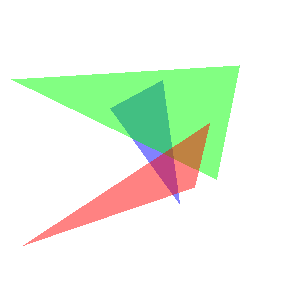

In [1]:
from PIL import Image, ImageDraw

polygons = [
    {'vertices': [(179, 203), (162, 80), (110, 108)],
     'RGBA': (0, 0, 255, 125)},
    {'vertices': [(239, 65), (216, 179), (11, 79)], 'RGBA': (0, 255, 0, 125)},
    {'vertices': [(209, 123), (23, 245), (194, 187)], 'RGBA': (255, 0, 0, 125)}
]


def draw(polygons, size):
    """ Функция для рисования многоугольников """

    img = Image.new('RGB', (size[0], size[1]), (255, 255, 255))
    drw = ImageDraw.Draw(img, 'RGBA')

    for pol in polygons:
        drw.polygon(pol['vertices'], pol['RGBA'])

    return (img.convert("RGB"))


draw(polygons, size=(300, 300))

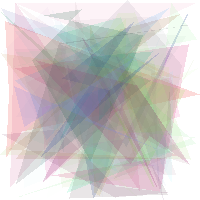

In [2]:
import numpy as np


def random_triangles(N, size, vertices=3, colour="random", alpha="random"):
    """ Функция создания популяции рандомных треугольников """

    collection = []

    for i in range(N):
        coords = [(np.random.randint(0, size[0]), np.random.randint(0, size[1]))
                  for i in range(vertices)]

        if alpha == "random":
            a = np.random.randint(0, 50)
        else:
            a = alpha

        if colour == "white":
            rgba = (255, 255, 255, a)
        elif colour == "black":
            rgba = (0, 0, 0, a)
        elif colour == "random":
            rgba = (np.random.randint(0, 256), np.random.randint(
                0, 256), np.random.randint(0, 256), a)

        triangle = {"vertices": coords, "RGBA": rgba}
        collection.append(triangle)

    return (collection)


collection = random_triangles(N=50, size=(
    200, 200), vertices=5, colour="random", alpha="random")
img = draw(collection, size=(200, 200))
img

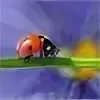

In [3]:
image_path = "bug.png"
target = Image.open(image_path).convert("RGB")
target

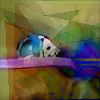

In [4]:
from PIL import ImageChops

ImageChops.difference(img, target)

In [ ]:
def pixel_difference(candidate, target):
    """ Функция для попиксельного вычисления отличий между картинками"""
    diff = ImageChops.difference(candidate, target)
    totdiff = np.array(diff.getdata()).sum()
    return (totdiff)


diff = pixel_difference(img, target)
diff

In [ ]:
def max_pixel_difference(target):
    """ Функция вычисления максимально возможной разницы между изображениями"""
    white = Image.new('RGB', target.size, (255, 255, 255))
    diff = ImageChops.difference(white, target)
    maxdiff = np.array(diff.getdata()).sum()
    return (maxdiff)


maxdiff = max_pixel_difference(target)
fitness = (1 - diff / maxdiff) * 100
print("Fitness = " + str(np.round(fitness, 4)) + "%")

In [5]:
import copy
import matplotlib.pyplot as plt


def mutation(original, size):
    """ Функция мутации"""
    mutant = copy.deepcopy(original)
    polidx = np.random.randint(len(mutant))

In [ ]:
def pop_fitness(pop, target):
    """
    Вычисляет приспособленность каждой популяции
    """

    size = target.size
    maxdiff = max_pixel_difference(target)

    fitvec = []

    for org in pop:
        img = draw(org[0], size)
        diff = pixel_difference(img, target)
        fitness = (1 - diff / maxdiff) * 100
        fitvec.append(fitness)

    return (fitvec)


def individ_fitness(individ, target):
    """
    Вычисление приспособленности индивида
    """

    size = target.size
    maxdiff = max_pixel_difference(target)

    img = draw(individ, size)
    diff = pixel_difference(img, target)
    fitness = (1 - diff / maxdiff) * 100

    return (fitness)

In [ ]:
def random_polygons(N, size, num_verts=3, colour="random", alpha="random"):
    """ Создание рандомных многоугольников """

    collection = []

    for i in range(N):
        coords = [(np.random.randint(-10, size[0]+10),
                   np.random.randint(-10, size[1]+10)) for i in range(num_verts)]

        if alpha == "random":
            a = np.random.randint(0, 50)
        else:
            a = alpha

        if colour == "white":
            rgba = (255, 255, 255, a)
        elif colour == "black":
            rgba = (0, 0, 0, a)
        elif colour == "random":
            rgba = (np.random.randint(0, 256), np.random.randint(
                0, 256), np.random.randint(0, 256), a)

        triangle = {"vertices": coords, "RGBA": rgba}
        collection.append(triangle)

    return (collection)


def create_pop(Npop, N, size, num_verts=3, colour_init="black", alpha_init=100):
    """
    Создание популяции рандомных особей
    Каждая особь имеет N рандомно созданных многоугольников
    """

    pop = []
    for i in range(Npop):
        individ = random_polygons(
            N, size, num_verts=num_verts, colour=colour_init, alpha=alpha_init)
        fitness = individ_fitness(individ, target)
        pop.append((individ, fitness))

    pop = sorted(pop, key=lambda x: (x[1]), reverse=True)
    return pop


pop = create_pop(Npop=20, N=100, size=(200, 200), num_verts=2,
                 colour_init="random", alpha_init="random")

In [ ]:
def crossover(parent1, parent2, size, pmut=0.1):
    """
    Функция кроссинговера
    """

In [ ]:
def new_generation(pop, fitness, size, pmut=0.1, num_of_olds=0.5):
    """Функция создания нового (следующего) поколения"""

In [5]:
import pandas as pd
import time


def mean(list):
    sum = 0
    for elem in list:
        sum += elem[1]
    return sum/len(list)


def genetic_triangle_painting(target, Npop, Ntri=100, num_verts=3, maxgen=10, every=20, pmut=0.1, num_of_olds=0.1, colour_init="random", alpha_init="random", logs=True, outdir="output_images"):

    size = target.size

    pop_time = time.time()
    pop = create_pop(Npop=Npop, N=Ntri, size=size, num_verts=num_verts,
                     colour_init=colour_init, alpha_init=alpha_init)
    fitness = pop_fitness(pop, target)
    pop_time = time.time() - pop_time

    info = []
    maxfit = 0

    for i in range(maxgen+1):
        maxfit = pop[0][1]
        if i % every == 0:
            avgfit = mean(pop)

            best = pop[0][0]
            best_img = draw(best, size=size)
            outpath = outdir + "/generation_" + str(i) + ".png"
            best_img.save(outpath)
            info.append([i, maxfit, avgfit, pop_time, outpath])
            if logs == True:
                print("Generation: " + str(i) + "    Max. Fitness: " + str(np.round(maxfit, 2)) +
                      "%    Avg. Fitness: " + str(np.round(avgfit, 2)) + "%" + "   Time: "+str(pop_time))

        pop_time = time.time()
        newpop = new_generation(pop, fitness, size=size,
                                pmut=pmut, num_of_olds=num_of_olds)
        fitness = pop_fitness(newpop, target)
        pop_time = time.time() - pop_time
        pop = newpop

    dfout = pd.DataFrame(
        info, columns=["generation", "max_fitness", "avg_fitness", "time", "outpath"])
    return (dfout)